In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
from pathlib import Path

# ── Configuration ─────────────────────────────────────────────────────────────
OUTPUT_ROOT = Path("output/grid_day")

TEMPERATURES = [200, 400, 600, 800, 1000, 1200, 1400, 1600]  # K

COMPOSITIONS = {
    "EH3":         "EH3",
    "EL3":         "EL3",
    "R3":          "R3",
    "Krymka(LL3)": "Krymka(LL3)",
    "Bath(H4)":    "Bath(H4)",
}

PASSES = ["A", "B", "C", "D", "E"]

FIXED_COLS = {
    "grid_point", "iterations", "chem_iter", "cond_iter",
    "converged", "elem_conserved", "p_bar", "T_K",
    "ntot_cmneg3", "n_g_cmneg3", "m_u",
}

# Resolution categories in priority order
RESOLUTIONS = ["originally_ok"] + [f"pass{p}" for p in PASSES] + ["unsolved"]

RESOLUTION_COLORS = {
    "originally_ok": "#cccccc",  # light gray
    "passA":         "#2ca02c",  # green
    "passB":         "#98df8a",  # light green
    "passC":         "#1f77b4",  # blue
    "passD":         "#aec7e8",  # light blue
    "passE":         "#9467bd",  # purple  ← joint Newton fix
    "unsolved":      "#d62728",  # red
}

RESOLUTION_LABELS = {
    "originally_ok": "Originally OK",
    "passA":         "Fixed by Pass A (accuracyChem=1e-7)",
    "passB":         "Fixed by Pass B (condUseSVD)",
    "passC":         "Fixed by Pass C (more iterations)",
    "passD":         "Fixed by Pass D (condIterChangeLimit=50)",
    "passE":         "Fixed by Pass E (nbSwitchToJoint=0)",
    "unsolved":      "Still failing",
}

MS_OK = 8   # marker size for originally-OK points
MS_BAD = 18 # larger markers for failing/fixed points so they stand out

In [3]:
def parse_monitor(path):
    """Parse a FastChem monitor.dat into a DataFrame (ok/fail → bool)."""
    with open(path) as f:
        header_line = f.readline().lstrip("#").strip()

    raw_cols = [c.strip() for c in header_line.split("\t") if c.strip()]
    cols = [
        c.replace("(", "_").replace(")", "")
         .replace("-", "neg").replace("<", "").replace(">", "")
        for c in raw_cols
    ]

    df = pd.read_csv(path, sep=r"\s+", comment="#", header=None, names=cols)

    bool_cols = [c for c in ["converged", "elem_conserved"] if c in df.columns]
    bool_cols += [c for c in cols[11:] if c in df.columns]
    for col in bool_cols:
        if df[col].dtype == object:
            df[col] = df[col].str.strip() == "ok"
        else:
            df[col] = df[col].astype(bool)

    return df


def point_is_failing(row):
    """True if this grid point failed convergence or element conservation."""
    if "converged" in row.index and not bool(row["converged"]):
        return True
    if "elem_conserved" in row.index and not bool(row["elem_conserved"]):
        return True
    return False


def monitor_is_failing(df):
    """Boolean Series: True where a row failed."""
    fail = pd.Series(False, index=df.index)
    if "converged" in df.columns:
        fail |= ~df["converged"].astype(bool)
    if "elem_conserved" in df.columns:
        fail |= ~df["elem_conserved"].astype(bool)
    return fail


def load_retry_resolution():
    """
    Build a flat DataFrame with one row per (composition, T_eq, grid_point).

    Columns:
      comp, T_eq, T_K, p_bar, originally_ok (bool), resolution (str)

    resolution is one of:
      'originally_ok' | 'passA' | 'passB' | 'passC' | 'passD' | 'unsolved'
    """
    records = []

    for label, slug in COMPOSITIONS.items():
        for T_eq in TEMPERATURES:
            chem_dir = OUTPUT_ROOT / f"{T_eq}K_{slug}_day" / "chemistry"
            orig_path = chem_dir / "monitor.dat"
            if not orig_path.exists():
                continue

            try:
                orig = parse_monitor(orig_path)
            except Exception as exc:
                print(f"  WARNING: cannot parse {orig_path}: {exc}")
                continue

            orig_fail = monitor_is_failing(orig)

            # Load retry pass monitors (only exist when original had failures)
            retry_dir = chem_dir / "retry"
            pass_fail = {}  # pass_label → boolean Series (True = still failing)
            for p in PASSES:
                pp = retry_dir / f"monitor_pass{p}.dat"
                if pp.exists():
                    try:
                        pdf = parse_monitor(pp)
                        pass_fail[p] = monitor_is_failing(pdf)
                    except Exception as exc:
                        print(f"  WARNING: cannot parse {pp}: {exc}")

            for i in range(len(orig)):
                row = orig.iloc[i]
                if not orig_fail.iloc[i]:
                    resolution = "originally_ok"
                else:
                    resolution = "unsolved"
                    for p in PASSES:
                        if p in pass_fail and not pass_fail[p].iloc[i] and pass_fail[p].sum() < orig_fail.sum():
                            resolution = f"pass{p}"
                            break

                records.append({
                    "comp":         label,
                    "T_eq":         T_eq,
                    "T_K":          row["T_K"]   if "T_K"   in row.index else np.nan,
                    "p_bar":        row["p_bar"]  if "p_bar" in row.index else np.nan,
                    "originally_ok": not orig_fail.iloc[i],
                    "resolution":   resolution,
                })

    return pd.DataFrame(records)


print("Loading original and retry monitor files...")
df_all = load_retry_resolution()
print(f"Loaded {len(df_all):,} grid points across {df_all['comp'].nunique()} compositions.\n")

orig_fail  = df_all[~df_all["originally_ok"]]
n_orig_bad = len(orig_fail)
print(f"Originally failing points: {n_orig_bad}")
for res in RESOLUTIONS[1:]:   # skip 'originally_ok'
    n = (orig_fail["resolution"] == res).sum()
    print(f"  {RESOLUTION_LABELS[res]:45s}: {n}")

Loading original and retry monitor files...
Loaded 3,000 grid points across 5 compositions.

Originally failing points: 126
  Fixed by Pass A (accuracyChem=1e-7)          : 24
  Fixed by Pass B (condUseSVD)                 : 0
  Fixed by Pass C (more iterations)            : 0
  Fixed by Pass D (condIterChangeLimit=50)     : 0
  Fixed by Pass E (nbSwitchToJoint=0)          : 0
  Still failing                                : 102


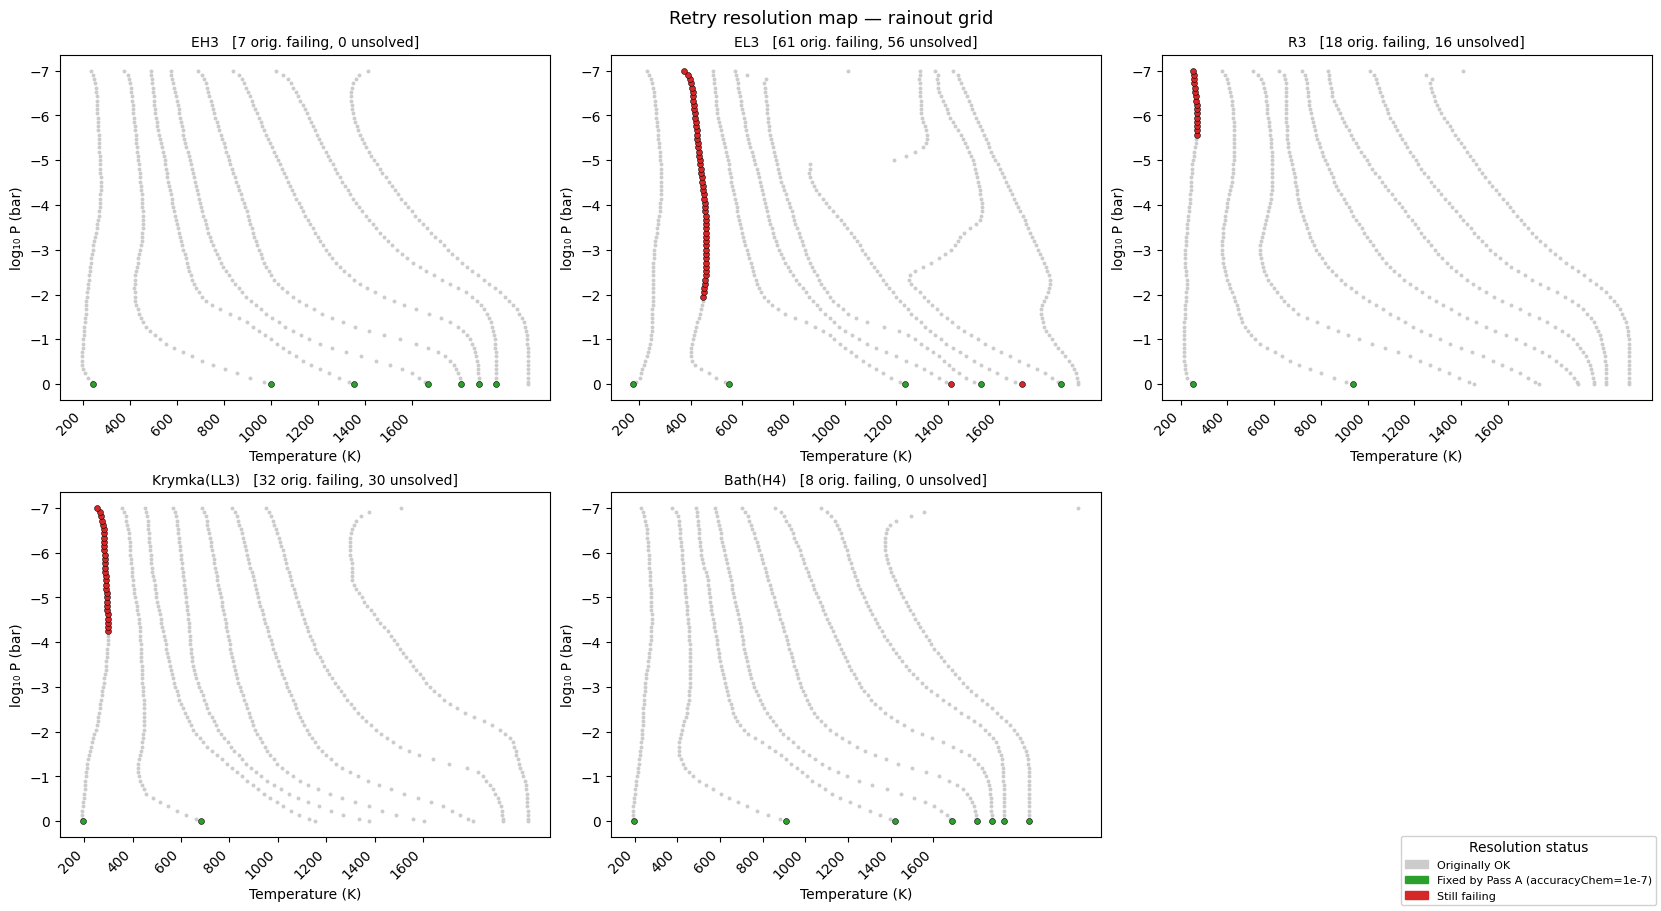

In [4]:
n = len(COMPOSITIONS)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows),
                          constrained_layout=True)
axes = np.array(axes).flatten()

for ax, label in zip(axes, COMPOSITIONS):
    sub = df_all[df_all["comp"] == label]

    # Draw originally-OK points first (background layer)
    ok  = sub[sub["resolution"] == "originally_ok"]
    ax.scatter(ok["T_K"], np.log10(ok["p_bar"]),
               c=RESOLUTION_COLORS["originally_ok"], s=MS_OK, linewidths=0, zorder=1)

    # Draw originally-failing points on top, colored by resolution
    bad = sub[sub["resolution"] != "originally_ok"]
    for res in RESOLUTIONS[1:]:   # passA … passD, unsolved
        pts = bad[bad["resolution"] == res]
        if pts.empty:
            continue
        ax.scatter(pts["T_K"], np.log10(pts["p_bar"]),
                   c=RESOLUTION_COLORS[res], s=MS_BAD, linewidths=0.4,
                   edgecolors="k", zorder=2)

    ax.set_xticks(TEMPERATURES)
    ax.set_xticklabels([str(t) for t in TEMPERATURES], rotation=45, ha="right")
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("log₁₀ P (bar)")
    ax.invert_yaxis()

    n_bad     = len(bad)
    n_unsolved = (bad["resolution"] == "unsolved").sum()
    ax.set_title(f"{label}   [{n_bad} orig. failing, {n_unsolved} unsolved]", fontsize=10)

for ax in axes[n:]:
    ax.set_visible(False)

patches = [mpatches.Patch(color=RESOLUTION_COLORS[r], label=RESOLUTION_LABELS[r])
           for r in RESOLUTIONS if r in df_all["resolution"].values]
fig.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.9,
           title="Resolution status")
fig.suptitle("Retry resolution map — rainout grid", fontsize=13)
plt.show()

In [5]:
type_2_failures = [{"T_eq": 400, "comp": "EL3"}, {"T_eq": 200, "comp": "R3"}, {"T_eq": 200, "comp": "Krymka(LL3)"}]

In [6]:
#find pressure levels where type 2 failures start
for failure in type_2_failures:
    sub = df_all[(df_all["comp"] == failure["comp"]) & (df_all["T_eq"] == failure["T_eq"])]
    sub_fail = sub[sub["resolution"] == "unsolved"]
    if not sub_fail.empty:
        p_max = sub_fail["p_bar"].max()
        print(f"{failure['comp']} at {failure['T_eq']} K: type 2 failures start below ~{p_max:.2e} bar")
        failure["p_max"] = p_max
    else:
        print(f"{failure['comp']} at {failure['T_eq']} K: no unsolved failures found")

EL3 at 400 K: type 2 failures start below ~1.12e-02 bar
R3 at 200 K: type 2 failures start below ~2.68e-06 bar
Krymka(LL3) at 200 K: type 2 failures start below ~5.78e-05 bar


In [7]:
type_2_failures

[{'T_eq': 400, 'comp': 'EL3', 'p_max': 0.0111588},
 {'T_eq': 200, 'comp': 'R3', 'p_max': 2.6827e-06},
 {'T_eq': 200, 'comp': 'Krymka(LL3)', 'p_max': 5.77969e-05}]

In [8]:
#load condensate data for type 2 failures to check if they correlate with condensate formation
cond_data = {}
for failure in type_2_failures:
    chem_dir = OUTPUT_ROOT / f"{failure['T_eq']}K_{COMPOSITIONS[failure['comp']]}_day" / "chemistry"
    cond_path = chem_dir / "condensates.dat"
    if cond_path.exists():
        try:
            cond_df = pd.read_csv(cond_path, sep=r"\s+")
            cond_data[(failure["comp"], failure["T_eq"])] = cond_df
        except Exception as exc:
            print(f"  WARNING: cannot parse {cond_path}: {exc}")
    else:
        print(f"  WARNING: condensate data not found at {cond_path}")

In [9]:
# find condensates that form right before the type 2 failures start
for failure in type_2_failures:
    key = (failure["comp"], failure["T_eq"])
    if key not in cond_data:
        print(f"No condensate data for {failure['comp']} at {failure['T_eq']} K")
        continue

    cond_df = cond_data[key]
    p_max = failure.get("p_max", None)
    if p_max is None:
        print(f"No p_max for {failure['comp']} at {failure['T_eq']} K, cannot check condensates")
        continue
    # get pressure level of the row with pressure just above p_max
    i_p_max = cond_df[cond_df["#p(bar)"]==p_max].index
    if len(i_p_max) == 0:
        print(f"No exact match for p_max={p_max:.2e} bar in condensate data for {failure['comp']} at {failure['T_eq']} K")
        continue
    i_p_max = i_p_max[0]

    forming_condensates = []
    for col in cond_df.columns:
        if col in FIXED_COLS:
            continue
        if '(s' in col or '(l' in col:
            if cond_df[col].iloc[i_p_max-1] > 0:
                forming_condensates.append(col)
    print(f"{failure['comp']} at {failure['T_eq']} K: condensates forming just below failure threshold: at {cond_df["#p(bar)"].iloc[i_p_max-1]:.1e} {forming_condensates}")


    forming_condensates = []
    for col in cond_df.columns:
        if col in FIXED_COLS:
            continue
        if '(s' in col or '(l' in col:
            if cond_df[col].iloc[i_p_max] > 0:
                forming_condensates.append(col)
    print(f"{failure['comp']} at {failure['T_eq']} K: condensates forming at failure threshold: at {cond_df["#p(bar)"].iloc[i_p_max]:.1e} {forming_condensates}")       
    

EL3 at 400 K: condensates forming just below failure threshold: at 1.4e-02 ['C(s)']
EL3 at 400 K: condensates forming at failure threshold: at 1.1e-02 ['C(s)']
R3 at 200 K: condensates forming just below failure threshold: at 3.3e-06 ['C(s)', 'SiO2(s,l)']
R3 at 200 K: condensates forming at failure threshold: at 2.7e-06 ['C(s)', 'SiO2(s,l)']
Krymka(LL3) at 200 K: condensates forming just below failure threshold: at 7.2e-05 []
Krymka(LL3) at 200 K: condensates forming at failure threshold: at 5.8e-05 ['C(s)']


In [10]:
#find C/O ratio at the failure points in the gas phase
gas_data = {}
for failure in type_2_failures:
    chem_dir = OUTPUT_ROOT / f"{failure['T_eq']}K_{COMPOSITIONS[failure['comp']]}_day" / "chemistry"
    cond_path = chem_dir / "chem.dat"
    if cond_path.exists():
        try:
            cond_df = pd.read_csv(cond_path, sep=r"\s+")
            cond_data[(failure["comp"], failure["T_eq"])] = cond_df
        except Exception as exc:
            print(f"  WARNING: cannot parse {cond_path}: {exc}")
    else:
        print(f"  WARNING: chem data not found at {cond_path}")

In [12]:
#get top few gas species by number density at the failure points
for failure in type_2_failures:
    key = (failure["comp"], failure["T_eq"])
    if key not in cond_data:
        print(f"No chem data for {failure['comp']} at {failure['T_eq']} K")
        continue

    chem_df = cond_data[key]
    p_max = failure.get("p_max", None)
    if p_max is None:
        print(f"No p_max for {failure['comp']} at {failure['T_eq']} K, cannot check gas composition")
        continue
    # get pressure level of the row with pressure just above p_max
    i_p_max = chem_df[chem_df["#p(bar)"]==p_max].index
    if len(i_p_max) == 0:
        print(f"No exact match for p_max={p_max:.2e} bar in chem data for {failure['comp']} at {failure['T_eq']} K")
        continue
    i_p_max = i_p_max[0]

    gas_cols = [col for col in chem_df.columns if (col not in FIXED_COLS) and "(" not in col]
    top_gas = chem_df.loc[i_p_max, gas_cols].nlargest(5)
    print(f"{failure['comp']} at {failure['T_eq']} K: top gas species at failure threshold: at {chem_df["#p(bar)"].iloc[i_p_max]:.3e} {top_gas.to_dict()}")

EL3 at 400 K: top gas species at failure threshold: at 1.116e-02 {'C1H4': 1.0, 'N2': 0.16025340485, 'H2': 0.066190696431, 'H2O1': 0.00011268533424, 'H3N1': 8.7299597112e-05}
R3 at 200 K: top gas species at failure threshold: at 2.683e-06 {'C1H4': 1.0, 'N2': 0.046512078506, 'H2': 0.0043683899229, 'H2O1': 6.8745607298e-05, 'H3N1': 9.8932727865e-07}
Krymka(LL3) at 200 K: top gas species at failure threshold: at 5.780e-05 {'C1H4': 1.0, 'H2': 0.0041669073817, 'N2': 0.001387734285, 'H3N1': 4.7902747085e-07, 'H2O1': 2.024663035e-07}
